In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [55]:
df = pd.read_csv("data/train.csv")

In [56]:
df.describe()

,ID,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,DAYS_AGE,DAYS_EMPLOYMENT,DAYS_ID_PUBLISH,OWN_CAR_AGE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_4,TARGET
count,215257.000000,215257.000000,2.152570e+05,2.152570e+05,215249.000000,2.150540e+05,215257.000000,215257.000000,215257.000000,73305.000000,...,215257.000000,215257.000000,186162.000000,186162.000000,186162.000000,186162.000000,186162.000000,186162.00000,2.147930e+05,215257.000000
mean,277916.285552,0.416567,1.683448e+05,5.996394e+05,27128.366938,5.388528e+05,-16040.968814,64138.989292,-2995.073206,12.053175,...,0.000506,0.000330,0.006494,0.006935,0.034486,0.268175,0.265264,1.90107,2.571639e-01,0.081057
std,102805.880546,0.721898,1.023409e+05,4.030145e+05,14521.116795,3.699160e+05,4367.736464,141546.368713,1509.053098,11.920288,...,0.022497,0.018158,0.084051,0.108859,0.203859,0.922865,0.860637,1.86733,1.850209e-01,0.272923
min,100002.000000,0.000000,2.565000e+04,4.500000e+04,1615.500000,4.050000e+04,-25201.000000,-17912.000000,-6383.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,2.436734e-08,0.000000
25%,188825.000000,0.000000,1.125000e+05,2.700000e+05,16551.000000,2.385000e+05,-19697.000000,-2758.000000,-4298.000000,5.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,9.779965e-02,0.000000
50%,277695.000000,0.000000,1.462500e+05,5.155290e+05,24930.000000,4.500000e+05,-15756.000000,-1209.000000,-3257.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,2.257796e-01,0.000000
75%,366772.000000,1.000000,2.025000e+05,8.086500e+05,34605.000000,6.795000e+05,-12409.000000,-288.000000,-1722.000000,15.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.00000,3.940680e-01,0.000000
max,456255.000000,19.000000,9.000000e+06,4.050000e+06,230161.500000,4.050000e+06,-7676.000000,365243.000000,0.000000,91.000000,...,1.000000,1.000000,3.000000,9.000000,8.000000,27.000000,261.000000,25.00000,8.059096e-01,1.000000


In [57]:
columns_to_keep = [
    'DAYS_AGE',
    'NAME_INCOME_TYPE',
    'DAYS_EMPLOYMENT',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'AMT_ANNUITY',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'AMT_INCOME_TOTAL',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_HOUSING_TYPE',
    'AMT_CREDIT',
    'TARGET'
]

df_final = df[columns_to_keep]

print("Final DataFrame Shape:", df_final.shape)
print("\nFirst 3 rows:")
print(df_final.head(3))

Final DataFrame Shape: (215257, 14)

First 3 rows:
   DAYS_AGE      NAME_INCOME_TYPE  DAYS_EMPLOYMENT  \
0    -22008             Pensioner           365243   
1     -8506  Commercial associate             -313   
2    -11579               Working            -2651   

             NAME_EDUCATION_TYPE    NAME_FAMILY_STATUS  AMT_ANNUITY  \
0  Secondary / secondary special                 Widow      37800.0   
1  Secondary / secondary special  Single / not married      40963.5   
2  Secondary / secondary special               Married      19795.5   

   CNT_CHILDREN  CNT_FAM_MEMBERS  AMT_INCOME_TOTAL FLAG_OWN_CAR  \
0             0              1.0          427500.0            N   
1             0              1.0          180000.0            Y   
2             1              3.0          112500.0            Y   

  FLAG_OWN_REALTY  NAME_HOUSING_TYPE  AMT_CREDIT  TARGET  
0               Y  House / apartment   1288350.0       0  
1               Y  House / apartment    848745.0       0  
2

In [58]:
df_final.describe()

,DAYS_AGE,DAYS_EMPLOYMENT,AMT_ANNUITY,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,AMT_CREDIT,TARGET
count,215257.000000,215257.000000,215249.000000,215257.000000,215255.000000,2.152570e+05,2.152570e+05,215257.000000
mean,-16040.968814,64138.989292,27128.366938,0.416567,2.150882,1.683448e+05,5.996394e+05,0.081057
std,4367.736464,141546.368713,14521.116795,0.721898,0.910791,1.023409e+05,4.030145e+05,0.272923
min,-25201.000000,-17912.000000,1615.500000,0.000000,1.000000,2.565000e+04,4.500000e+04,0.000000
25%,-19697.000000,-2758.000000,16551.000000,0.000000,2.000000,1.125000e+05,2.700000e+05,0.000000
50%,-15756.000000,-1209.000000,24930.000000,0.000000,2.000000,1.462500e+05,5.155290e+05,0.000000
75%,-12409.000000,-288.000000,34605.000000,1.000000,3.000000,2.025000e+05,8.086500e+05,0.000000
max,-7676.000000,365243.000000,230161.500000,19.000000,20.000000,9.000000e+06,4.050000e+06,1.000000


In [59]:
missing_counts = df_final.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

cols_with_missing = df_final[missing_counts.index].columns
df_final[cols_with_missing] = df_final[cols_with_missing].fillna(df_final[cols_with_missing].median())

C:\Users\user\AppData\Local\Temp\ipykernel_11312\543198922.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[cols_with_missing] = df_final[cols_with_missing].fillna(df_final[cols_with_missing].median())


In [60]:
df_final.shape

(215257, 14)

In [61]:
df_final['AGE_YEARS'] = abs(df_final['DAYS_AGE']) // 365
df_final['YEARS_EMPLOYED'] = abs(df_final['DAYS_EMPLOYMENT']) // 365

df_final = df_final.drop(columns=['DAYS_AGE', 'DAYS_EMPLOYMENT'])
df_final

C:\Users\user\AppData\Local\Temp\ipykernel_11312\1070940031.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['AGE_YEARS'] = abs(df_final['DAYS_AGE']) // 365
C:\Users\user\AppData\Local\Temp\ipykernel_11312\1070940031.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final['YEARS_EMPLOYED'] = abs(df_final['DAYS_EMPLOYMENT']) // 365


,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,AMT_ANNUITY,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,AMT_CREDIT,TARGET,AGE_YEARS,YEARS_EMPLOYED
0,Pensioner,Secondary / secondary special,Widow,37800.0,0,1.0,427500.0,N,Y,House / apartment,1288350.0,0,60,1000
1,Commercial associate,Secondary / secondary special,Single / not married,40963.5,0,1.0,180000.0,Y,Y,House / apartment,848745.0,0,23,0
2,Working,Secondary / secondary special,Married,19795.5,1,3.0,112500.0,Y,Y,Rented apartment,385164.0,0,31,7
3,Pensioner,Secondary / secondary special,Married,60867.0,0,2.0,540000.0,N,Y,House / apartment,1433520.0,0,58,1000
4,Working,Secondary / secondary special,Married,26316.0,0,2.0,76500.0,Y,Y,House / apartment,900000.0,0,58,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,Working,Secondary / secondary special,Married,70956.0,0,2.0,144000.0,Y,N,House / apartment,701730.0,0,50,4
215253,Working,Secondary / secondary special,Married,14751.0,1,3.0,148500.0,N,N,With parents,254700.0,0,29,6
215254,Commercial associate,Incomplete higher,Civil marriage,30258.0,0,2.0,270000.0,Y,Y,House / apartment,1030500.0,0,42,5
215255,Working,Secondary / secondary special,Separated,19206.0,0,1.0,225000.0,N,Y,House / apartment,433057.5,1,53,4


In [62]:
abnormal_age_count = (df_final['AGE_YEARS'] > 70).sum()
print(f"Number of people over 70 years old: {abnormal_age_count}")

# 2. Count unrealistic employment lengths (e.g., working > 50 years)
abnormal_emp_count = (df_final['YEARS_EMPLOYED'] > 50).sum()
print(f"Number of people working > 50 years: {abnormal_emp_count}")

anomaly_value = 1000
df_final['YEARS_EMPLOYED'] = df_final['YEARS_EMPLOYED'].replace(anomaly_value, np.nan)
df_final['FLAG_EMP_ANOMALY'] = df_final['YEARS_EMPLOYED'].isnull().astype(int)
df_final['YEARS_EMPLOYED'] = df_final['YEARS_EMPLOYED'].fillna(0)

df_final

Number of people over 70 years old: 0
Number of people working > 50 years: 38952


,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,AMT_ANNUITY,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,AMT_CREDIT,TARGET,AGE_YEARS,YEARS_EMPLOYED,FLAG_EMP_ANOMALY
0,Pensioner,Secondary / secondary special,Widow,37800.0,0,1.0,427500.0,N,Y,House / apartment,1288350.0,0,60,0.0,1
1,Commercial associate,Secondary / secondary special,Single / not married,40963.5,0,1.0,180000.0,Y,Y,House / apartment,848745.0,0,23,0.0,0
2,Working,Secondary / secondary special,Married,19795.5,1,3.0,112500.0,Y,Y,Rented apartment,385164.0,0,31,7.0,0
3,Pensioner,Secondary / secondary special,Married,60867.0,0,2.0,540000.0,N,Y,House / apartment,1433520.0,0,58,0.0,1
4,Working,Secondary / secondary special,Married,26316.0,0,2.0,76500.0,Y,Y,House / apartment,900000.0,0,58,37.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,Working,Secondary / secondary special,Married,70956.0,0,2.0,144000.0,Y,N,House / apartment,701730.0,0,50,4.0,0
215253,Working,Secondary / secondary special,Married,14751.0,1,3.0,148500.0,N,N,With parents,254700.0,0,29,6.0,0
215254,Commercial associate,Incomplete higher,Civil marriage,30258.0,0,2.0,270000.0,Y,Y,House / apartment,1030500.0,0,42,5.0,0
215255,Working,Secondary / secondary special,Separated,19206.0,0,1.0,225000.0,N,Y,House / apartment,433057.5,1,53,4.0,0


In [63]:
df_final['CREDIT_INCOME_RATIO'] = df_final['AMT_CREDIT'] / df_final['AMT_INCOME_TOTAL']
df_final['ADULT_IN_HOUSE'] = df_final['CNT_FAM_MEMBERS'] - df_final['CNT_CHILDREN']
df_final = df_final.drop(columns = ["AMT_CREDIT"])
df_final

,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,AMT_ANNUITY,CNT_CHILDREN,CNT_FAM_MEMBERS,AMT_INCOME_TOTAL,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,TARGET,AGE_YEARS,YEARS_EMPLOYED,FLAG_EMP_ANOMALY,CREDIT_INCOME_RATIO,ADULT_IN_HOUSE
0,Pensioner,Secondary / secondary special,Widow,37800.0,0,1.0,427500.0,N,Y,House / apartment,0,60,0.0,1,3.013684,1.0
1,Commercial associate,Secondary / secondary special,Single / not married,40963.5,0,1.0,180000.0,Y,Y,House / apartment,0,23,0.0,0,4.715250,1.0
2,Working,Secondary / secondary special,Married,19795.5,1,3.0,112500.0,Y,Y,Rented apartment,0,31,7.0,0,3.423680,2.0
3,Pensioner,Secondary / secondary special,Married,60867.0,0,2.0,540000.0,N,Y,House / apartment,0,58,0.0,1,2.654667,2.0
4,Working,Secondary / secondary special,Married,26316.0,0,2.0,76500.0,Y,Y,House / apartment,0,58,37.0,0,11.764706,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,Working,Secondary / secondary special,Married,70956.0,0,2.0,144000.0,Y,N,House / apartment,0,50,4.0,0,4.873125,2.0
215253,Working,Secondary / secondary special,Married,14751.0,1,3.0,148500.0,N,N,With parents,0,29,6.0,0,1.715152,2.0
215254,Commercial associate,Incomplete higher,Civil marriage,30258.0,0,2.0,270000.0,Y,Y,House / apartment,0,42,5.0,0,3.816667,2.0
215255,Working,Secondary / secondary special,Separated,19206.0,0,1.0,225000.0,N,Y,House / apartment,1,53,4.0,0,1.924700,1.0


In [65]:
df_final["ANNUITY_MONTHLY_INCOME_RATIO"] = df_final["AMT_ANNUITY"] / (df_final["AMT_INCOME_TOTAL"]/12)
df_final = df_final.drop(columns = ["AMT_INCOME_TOTAL", "AMT_ANNUITY"])
df_final

,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,CNT_CHILDREN,CNT_FAM_MEMBERS,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,TARGET,AGE_YEARS,YEARS_EMPLOYED,FLAG_EMP_ANOMALY,CREDIT_INCOME_RATIO,ADULT_IN_HOUSE,ANNUITY_MONTHLY_INCOME_RATIO
0,Pensioner,Secondary / secondary special,Widow,0,1.0,N,Y,House / apartment,0,60,0.0,1,3.013684,1.0,1.061053
1,Commercial associate,Secondary / secondary special,Single / not married,0,1.0,Y,Y,House / apartment,0,23,0.0,0,4.715250,1.0,2.730900
2,Working,Secondary / secondary special,Married,1,3.0,Y,Y,Rented apartment,0,31,7.0,0,3.423680,2.0,2.111520
3,Pensioner,Secondary / secondary special,Married,0,2.0,N,Y,House / apartment,0,58,0.0,1,2.654667,2.0,1.352600
4,Working,Secondary / secondary special,Married,0,2.0,Y,Y,House / apartment,0,58,37.0,0,11.764706,2.0,4.128000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,Working,Secondary / secondary special,Married,0,2.0,Y,N,House / apartment,0,50,4.0,0,4.873125,2.0,5.913000
215253,Working,Secondary / secondary special,Married,1,3.0,N,N,With parents,0,29,6.0,0,1.715152,2.0,1.192000
215254,Commercial associate,Incomplete higher,Civil marriage,0,2.0,Y,Y,House / apartment,0,42,5.0,0,3.816667,2.0,1.344800
215255,Working,Secondary / secondary special,Separated,0,1.0,N,Y,House / apartment,1,53,4.0,0,1.924700,1.0,1.024320


In [67]:
corr_matrix = df_final[["ANNUITY_MONTHLY_INCOME_RATIO", "CREDIT_INCOME_RATIO", "ADULT_IN_HOUSE"]]

corr_matrix.corr()

,ANNUITY_MONTHLY_INCOME_RATIO,CREDIT_INCOME_RATIO,ADULT_IN_HOUSE
ANNUITY_MONTHLY_INCOME_RATIO,1.000000,0.788348,0.122360
CREDIT_INCOME_RATIO,0.788348,1.000000,0.127033
ADULT_IN_HOUSE,0.122360,0.127033,1.000000


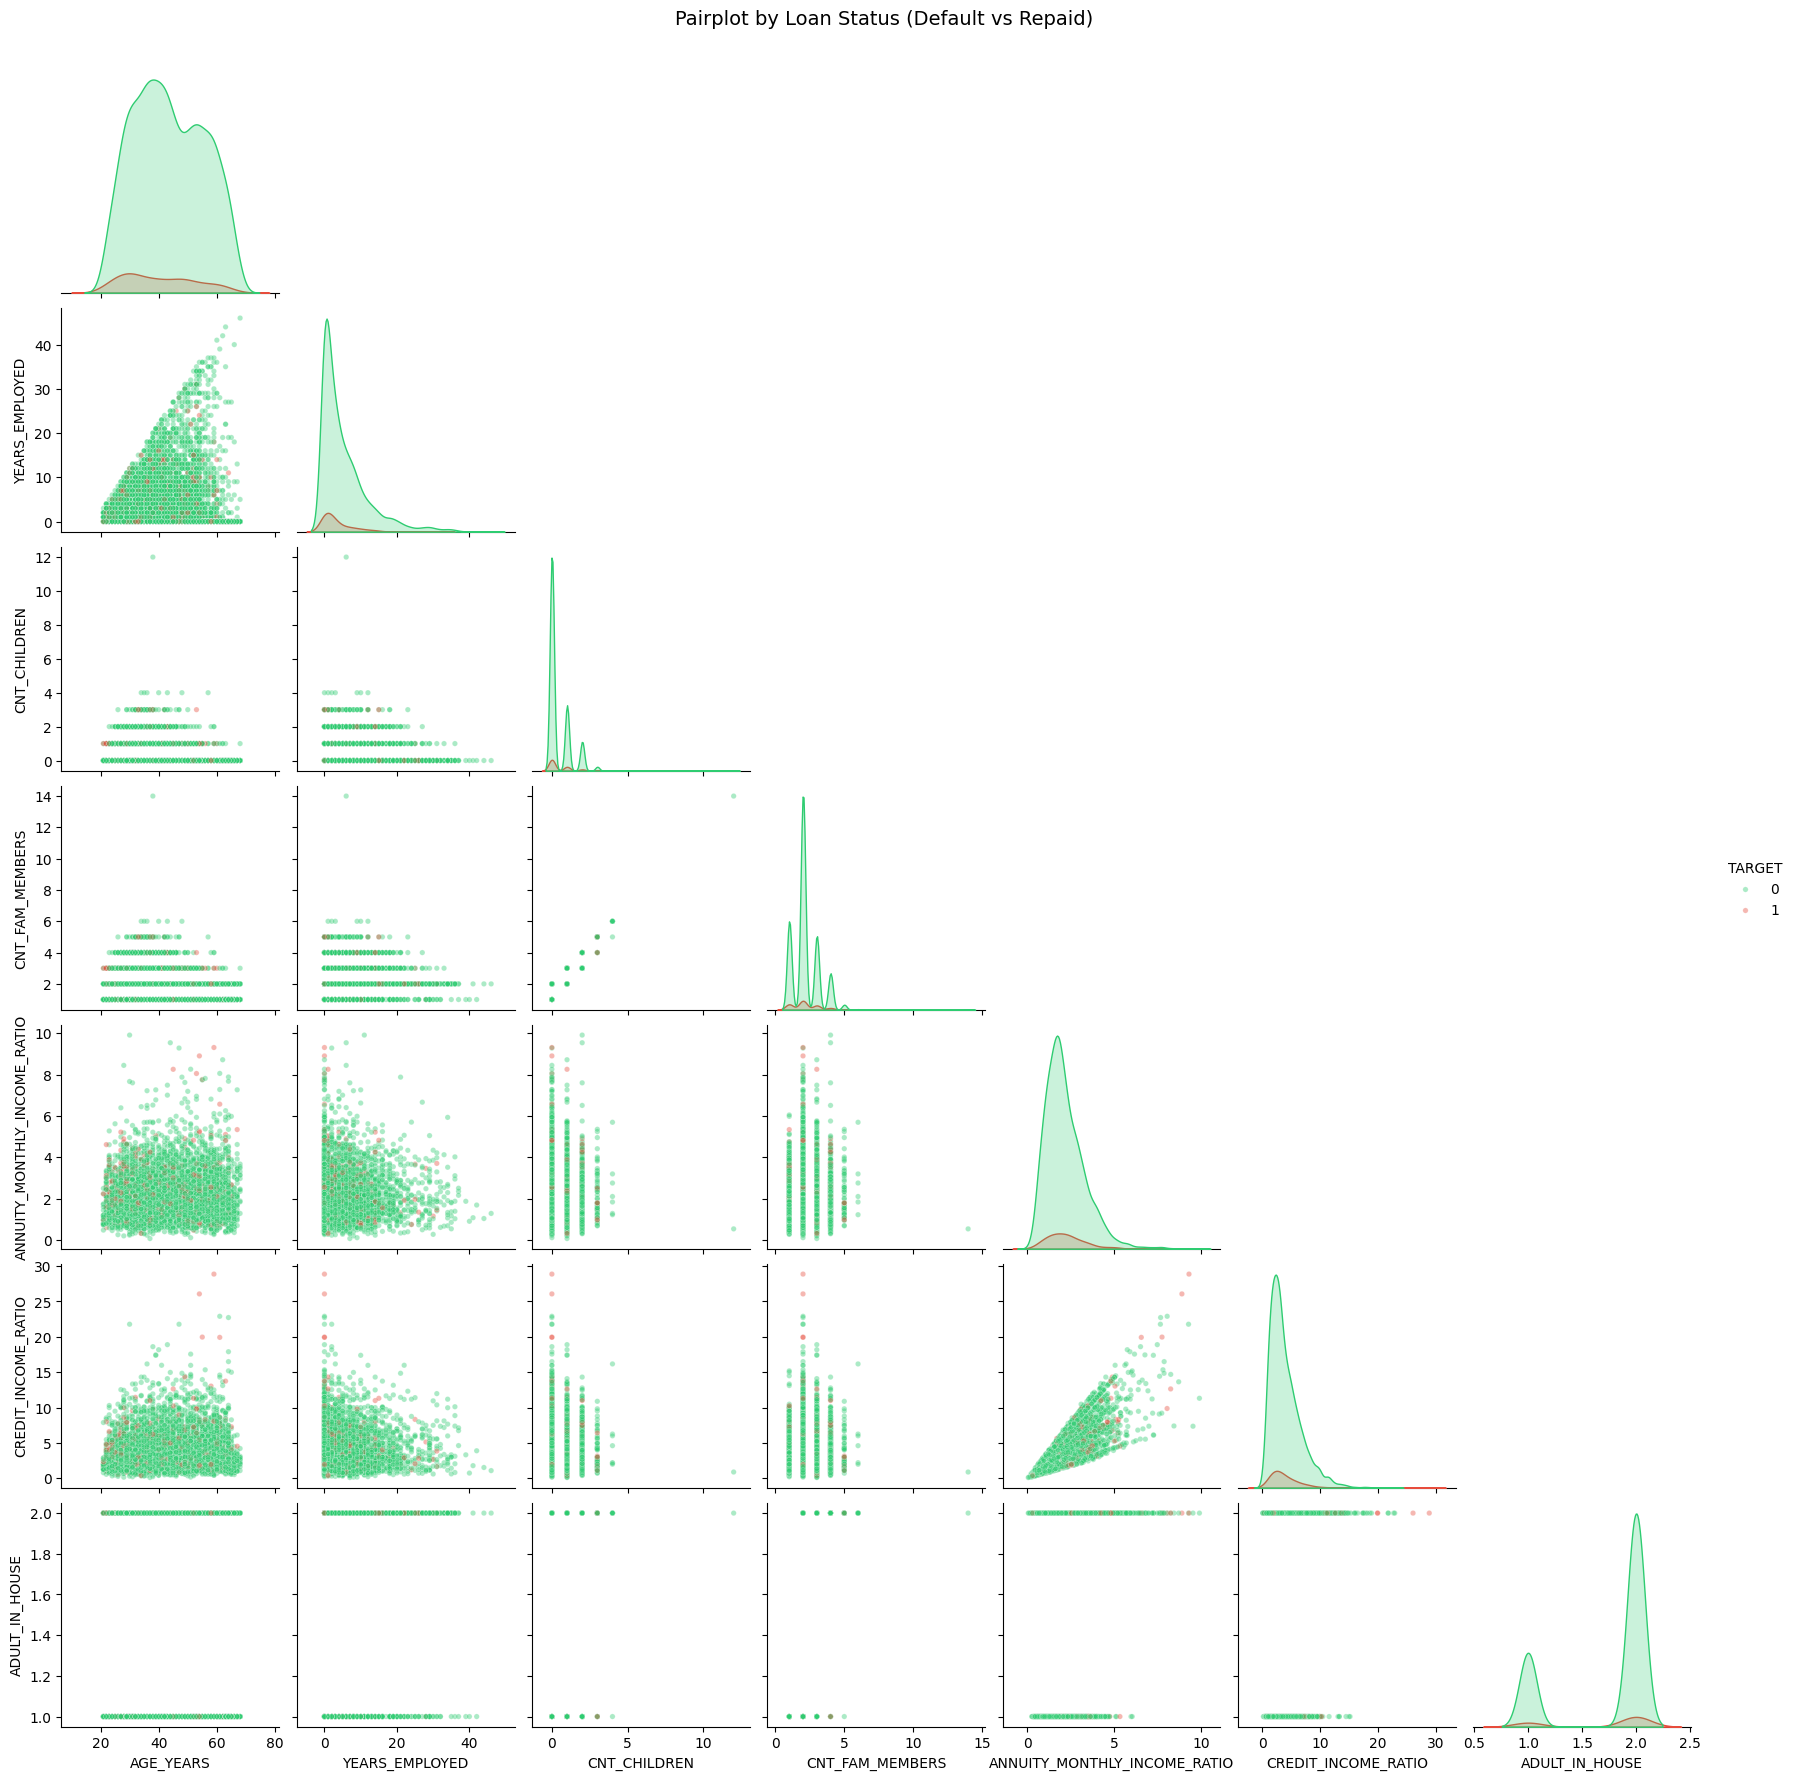

In [74]:
numerical_cols = [
    'AGE_YEARS', 'YEARS_EMPLOYED', 'CNT_CHILDREN', 
    'CNT_FAM_MEMBERS', 'ANNUITY_MONTHLY_INCOME_RATIO', 
    'CREDIT_INCOME_RATIO', "ADULT_IN_HOUSE"
]
# 1. Add your TARGET column to the list of numerical columns you want to plot
cols_for_pairplot = numerical_cols + ['TARGET']

# 2. Take your 5,000 row sample (CRITICAL: now including the TARGET column)
df_sample = df_final[cols_for_pairplot].sample(n=5000, random_state=42)

# 3. Draw the Pairplot with Color-Coding
sns.pairplot(
    df_sample, 
    hue='TARGET',                     # <--- THIS IS THE MAGIC PARAMETER
    diag_kind='kde', 
    corner=True, 
    palette={0: '#2ecc71', 1: '#e74c3c'},  # Green = Repaid (0), Red = Defaulted (1)
    plot_kws={'alpha': 0.4, 's': 15}       # alpha makes dots transparent, 's' makes them smaller
)

plt.suptitle("Pairplot by Loan Status (Default vs Repaid)", y=1.02, fontsize=14)
plt.show()

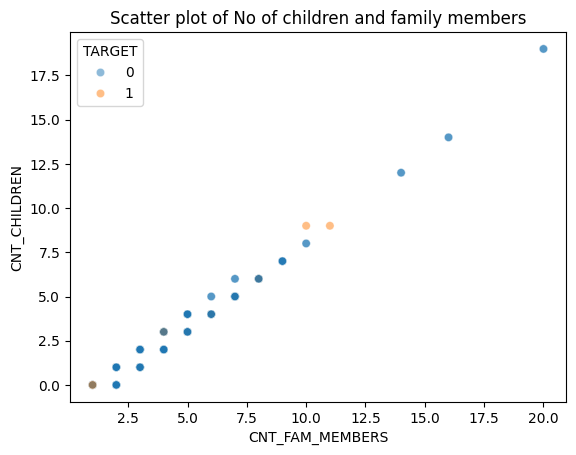

In [75]:
sns.scatterplot(data=df_final, x='CNT_FAM_MEMBERS', y='CNT_CHILDREN', hue='TARGET', alpha=0.5)

plt.title("Scatter plot of No of children and family members")
plt.show()

In [76]:
df[df["NAME_INCOME_TYPE"] == "Businessman"]

,ID,NAME_CONTRACT_TYPE,GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,...,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR,EXT_SOURCE_4,TARGET
11661,207018,Revolving loans,M,Y,Y,0,675000.0,540000.0,27000.0,540000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.047235,0
45333,254395,Revolving loans,M,Y,Y,0,450000.0,1350000.0,67500.0,1350000.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.413098,0
114466,347590,Revolving loans,F,Y,Y,0,900000.0,2250000.0,112500.0,2250000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.438714,0
117126,438579,Revolving loans,M,N,N,0,180000.0,495000.0,24750.0,495000.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.072219,0
159054,394662,Revolving loans,F,Y,Y,0,225000.0,225000.0,11250.0,225000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,2.0,0.251487,0
179197,201088,Revolving loans,M,Y,Y,1,180000.0,675000.0,33750.0,675000.0,...,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.547796,0
182320,134526,Revolving loans,M,N,N,0,2250000.0,1350000.0,67500.0,1350000.0,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,0.327959,0


In [77]:
# 1. Clean Income Type
income_to_replace = ['Unemployed', 'Student', 'Maternity leave']
df_final['NAME_INCOME_TYPE'] = df_final['NAME_INCOME_TYPE'].replace(income_to_replace, 'Other')

# 2. Clean Education Type
df_final['NAME_EDUCATION_TYPE'] = df_final['NAME_EDUCATION_TYPE'].replace(['Academic degree'], 'Higher education')

# 3. Clean Housing Type
housing_to_replace = ['Office apartment', 'Co-op apartment']
df_final['NAME_HOUSING_TYPE'] = df_final['NAME_HOUSING_TYPE'].replace(housing_to_replace, 'Other_Rented')
df_final['NAME_EDUCATION_TYPE'] = df_final['NAME_EDUCATION_TYPE'].replace('Secondary / secondary special', 'Secondary Education') 

# Verify the new, cleaner distributions
print(df_final['NAME_INCOME_TYPE'].value_counts())
print(df_final['NAME_HOUSING_TYPE'].value_counts())
print(df_final['NAME_EDUCATION_TYPE'].value_counts())

NAME_INCOME_TYPE
Working                 111213
Commercial associate     49950
Pensioner                38940
State servant            15113
Other                       34
Businessman                  7
Name: count, dtype: int64
NAME_HOUSING_TYPE
House / apartment      190886
With parents            10445
Municipal apartment      7859
Rented apartment         3421
Other_Rented             2646
Name: count, dtype: int64
NAME_EDUCATION_TYPE
Secondary Education    152963
Higher education        52392
Incomplete higher        7214
Lower secondary          2688
Name: count, dtype: int64


In [78]:
df_final

,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,CNT_CHILDREN,CNT_FAM_MEMBERS,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_HOUSING_TYPE,TARGET,AGE_YEARS,YEARS_EMPLOYED,FLAG_EMP_ANOMALY,CREDIT_INCOME_RATIO,ADULT_IN_HOUSE,ANNUITY_MONTHLY_INCOME_RATIO
0,Pensioner,Secondary Education,Widow,0,1.0,N,Y,House / apartment,0,60,0.0,1,3.013684,1.0,1.061053
1,Commercial associate,Secondary Education,Single / not married,0,1.0,Y,Y,House / apartment,0,23,0.0,0,4.715250,1.0,2.730900
2,Working,Secondary Education,Married,1,3.0,Y,Y,Rented apartment,0,31,7.0,0,3.423680,2.0,2.111520
3,Pensioner,Secondary Education,Married,0,2.0,N,Y,House / apartment,0,58,0.0,1,2.654667,2.0,1.352600
4,Working,Secondary Education,Married,0,2.0,Y,Y,House / apartment,0,58,37.0,0,11.764706,2.0,4.128000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
215252,Working,Secondary Education,Married,0,2.0,Y,N,House / apartment,0,50,4.0,0,4.873125,2.0,5.913000
215253,Working,Secondary Education,Married,1,3.0,N,N,With parents,0,29,6.0,0,1.715152,2.0,1.192000
215254,Commercial associate,Incomplete higher,Civil marriage,0,2.0,Y,Y,House / apartment,0,42,5.0,0,3.816667,2.0,1.344800
215255,Working,Secondary Education,Separated,0,1.0,N,Y,House / apartment,1,53,4.0,0,1.924700,1.0,1.024320


In [79]:
# Save the cleaned dataframe to a new CSV file
df_final.to_csv('data/cleaned_loan_data_revised.csv', index=False)

print("Success! The cleaned data has been saved as 'cleaned_loan_data_revised.csv'")

Success! The cleaned data has been saved as 'cleaned_loan_data_revised.csv'
